In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted")

Mounted at /content/drive
✓ Google Drive mounted


In [5]:
import os

BASE = "/content/drive/MyDrive/EyeMotionID"

folders = [
    "data/raw/MRL_Eye",
    "data/raw/MPIIGAZE",
    "data/raw/openeds",
    "data/processed",
    "data/sequences",
    "models/checkpoints",
    "notebooks",
    "src/detection",
    "src/features",
    "src/models",
    "src/utils",
    "results/plots",
    "results/reports",
    "docs"
]

for f in folders:
    os.makedirs(os.path.join(BASE, f), exist_ok=True)
    print(f"✓  {f}")

print("\n✓ Project structure created in Google Drive")

✓  data/raw/MRL_Eye
✓  data/raw/MPIIGAZE
✓  data/raw/openeds
✓  data/processed
✓  data/sequences
✓  models/checkpoints
✓  notebooks
✓  src/detection
✓  src/features
✓  src/models
✓  src/utils
✓  results/plots
✓  results/reports
✓  docs

✓ Project structure created in Google Drive


In [6]:
!pip install mediapipe -q

import torch, cv2, mediapipe, numpy, pandas, matplotlib, sklearn
print(f"PyTorch      {torch.__version__}")
print(f"OpenCV       {cv2.__version__}")
print(f"MediaPipe    {mediapipe.__version__}")
print(f"NumPy        {numpy.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("\n✓ All libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00
PyTorch      2.11.0+cpu
OpenCV       4.13.0
MediaPipe    0.10.35
NumPy        2.0.2
CUDA available: False

✓ All libraries ready


In [7]:
import os

OPENEDS_DIR = "/content/drive/MyDrive/EyeMotionID/data/raw/openeds"

print("=== Files in openeds folder ===")
for item in os.listdir(OPENEDS_DIR):
    full = os.path.join(OPENEDS_DIR, item)
    size = os.path.getsize(full) / (1024**3)
    print(f"  {item}  →  {size:.2f} GB")

=== Files in openeds folder ===
  openEDS.zip  →  8.02 GB


In [9]:
import os

OPENEDS_DIR = "/content/drive/MyDrive/EyeMotionID/data/raw/openeds"

print("=== openeds folder contents ===\n")
for item in sorted(os.listdir(OPENEDS_DIR)):
    full = os.path.join(OPENEDS_DIR, item)
    if os.path.isdir(full):
        # count files inside
        count = sum(len(files) for _, _, files in os.walk(full))
        size  = sum(
            os.path.getsize(os.path.join(r, f))
            for r, _, files in os.walk(full)
            for f in files
        ) / (1024**3)
        print(f"  [folder]  {item}/  →  {count:,} files  |  {size:.2f} GB")
    else:
        size = os.path.getsize(full) / (1024**3)
        print(f"  [file]    {item}  →  {size:.2f} GB")

=== openeds folder contents ===

  [folder]  bbox/  →  186 files  |  0.00 GB
  [folder]  openEDS/  →  8,048 files  |  1.49 GB
  [file]    openEDS.zip  →  8.02 GB


In [10]:
import os

zip_path = "/content/drive/MyDrive/EyeMotionID/data/raw/openeds/openEDS.zip"
os.remove(zip_path)
print("✓ Zip deleted — 8 GB freed")

✓ Zip deleted — 8 GB freed


In [11]:
OPENEDS_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/openeds/openEDS"

print("=== openEDS folder structure ===\n")
for root, dirs, files in os.walk(OPENEDS_PATH):
    dirs[:] = sorted(dirs)
    level = root.replace(OPENEDS_PATH, "").count(os.sep)
    if level > 2: continue
    indent = "    " * level + "├── "
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:3]:
        print(f"{'    '*(level+1)}├── {f}")
    if len(files) > 3:
        print(f"{'    '*(level+1)}└── ... {len(files)-3} more files")

=== openEDS folder structure ===

├── openEDS/
    ├── openEDS/
        ├── S_0/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 323 more files
        ├── S_1/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 312 more files
        ├── S_10/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 335 more files
        ├── S_101/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 288 more files
        ├── S_102/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 288 more files
        ├── S_103/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 288 more files
        ├── S_104/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── ... 288 more files
        ├── S_105/
            ├── 0.npy
            ├── 0.png
            ├── 1.npy
            └── 

## Day 6 — OpenEDS Dataset Exploration

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt

OPENEDS_PATH = "/content/drive/MyDrive/EyeMotionID/data/raw/openeds/openEDS/openEDS"
print("Path exists:", os.path.exists(OPENEDS_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path exists: True


In [13]:
subjects = sorted([d for d in os.listdir(OPENEDS_PATH)
                   if os.path.isdir(os.path.join(OPENEDS_PATH, d))])

print(f"Total subjects : {len(subjects)}")
print(f"Subject IDs    : {subjects[:5]} ... {subjects[-3:]}\n")

total_png = 0
total_npy = 0
for s in subjects:
    s_path = os.path.join(OPENEDS_PATH, s)
    pngs = [f for f in os.listdir(s_path) if f.endswith(".png")]
    npys = [f for f in os.listdir(s_path) if f.endswith(".npy")]
    total_png += len(pngs)
    total_npy += len(npys)

print(f"Total images (.png) : {total_png:,}")
print(f"Total labels (.npy) : {total_npy:,}")
print(f"Avg images/subject  : {total_png//len(subjects)}")

Total subjects : 27
Subject IDs    : ['S_0', 'S_1', 'S_10', 'S_101', 'S_102'] ... ['S_122', 'S_123', 'S_124']

Total images (.png) : 3,919
Total labels (.npy) : 4,129
Avg images/subject  : 145


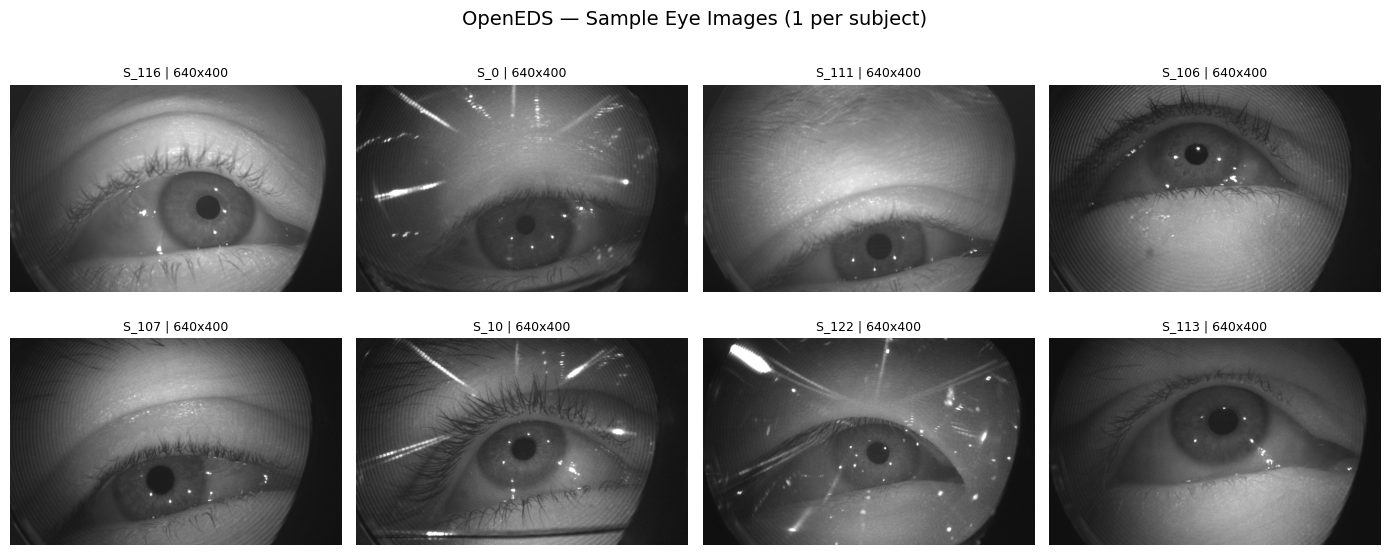

✓ Saved → results/plots/openeds_samples.png


In [14]:
# pick 8 random subjects
sample_subjects = random.sample(subjects, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("OpenEDS — Sample Eye Images (1 per subject)", fontsize=14)

for ax, s in zip(axes.flat, sample_subjects):
    s_path = os.path.join(OPENEDS_PATH, s)
    pngs   = [f for f in os.listdir(s_path) if f.endswith(".png")]
    img    = cv2.imread(os.path.join(s_path, random.choice(pngs)))
    img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{s} | {img.shape[1]}x{img.shape[0]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
os.makedirs("/content/drive/MyDrive/EyeMotionID/results/plots", exist_ok=True)
plt.savefig("/content/drive/MyDrive/EyeMotionID/results/plots/openeds_samples.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/openeds_samples.png")

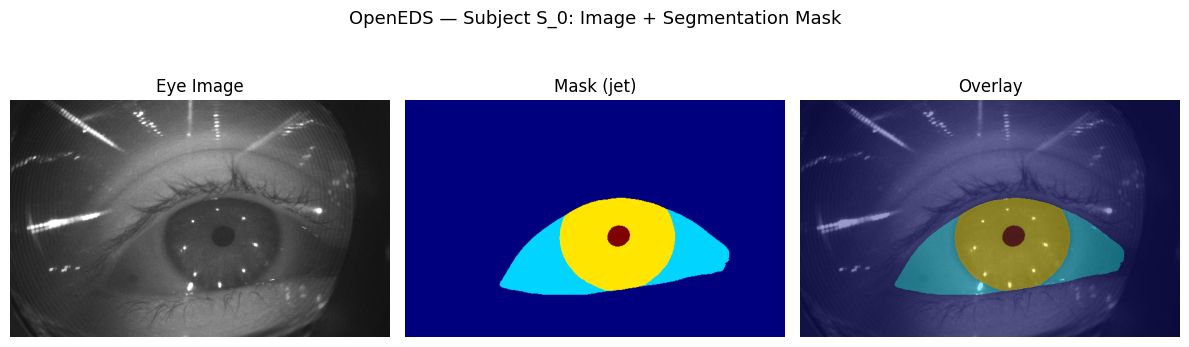

✓ Saved → results/plots/openeds_mask.png


In [15]:
# pick one subject and show image + its npy mask side by side
s       = subjects[0]
s_path  = os.path.join(OPENEDS_PATH, s)
img_path = os.path.join(s_path, "0.png")
npy_path = os.path.join(s_path, "0.npy")

img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = np.load(npy_path)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"OpenEDS — Subject {s}: Image + Segmentation Mask", fontsize=13)

axes[0].imshow(img);              axes[0].set_title("Eye Image");      axes[0].axis("off")
axes[1].imshow(mask, cmap="jet"); axes[1].set_title("Mask (jet)");     axes[1].axis("off")
axes[2].imshow(img);              axes[2].imshow(mask, cmap="jet", alpha=0.4)
axes[2].set_title("Overlay");     axes[2].axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/EyeMotionID/results/plots/openeds_mask.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/openeds_mask.png")

In [16]:
print("=" * 45)
print("   DAY 6 DATASET EXPLORATION SUMMARY")
print("=" * 45)
print()
print("Dataset → OpenEDS (Subset 1)")
print(f"  Subjects     : {len(subjects)}")
print(f"  Total images : {total_png:,}")
print(f"  Total masks  : {total_npy:,}")
print(f"  Format       : .png images + .npy segmentation masks")
print(f"  Labels       : iris, pupil, sclera regions")
print()
print("Use in project:")
print("  Week 2 → pupil region extraction")
print("  Week 3 → eye segmentation features for CNN")
print()
print("Plots saved → results/plots/")
print("  ✓ openeds_samples.png")
print("  ✓ openeds_mask.png")
print()
print("✓ Day 6 complete — ready for Day 7 (literature review report)")

   DAY 6 DATASET EXPLORATION SUMMARY

Dataset → OpenEDS (Subset 1)
  Subjects     : 27
  Total images : 3,919
  Total masks  : 4,129
  Format       : .png images + .npy segmentation masks
  Labels       : iris, pupil, sclera regions

Use in project:
  Week 2 → pupil region extraction
  Week 3 → eye segmentation features for CNN

Plots saved → results/plots/
  ✓ openeds_samples.png
  ✓ openeds_mask.png

✓ Day 6 complete — ready for Day 7 (literature review report)
